<a href="https://colab.research.google.com/github/allmore0/pp_501/blob/main/Proyecto_semestre_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [218]:
"""
Created on Tue Mar 10 19:16:04 2026

"""

'\nCreated on Tue Mar 10 19:16:04 2026\n\n'

#Proyecto Semestre 5
##Universidad Nacional Rosario Castellanos
##Grupo: 501

Autores:
- Gretel Kim Mendez Ortíz
- Alberto Lozano Morales



In [219]:
# Módulos importados para el proyecto
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import statsmodels.api as sm

# Kit de aprendizaje de ciencia
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from google.colab import drive

# Configuración visual para gráficos
sns.set_theme(style="whitegrid")

In [220]:
GITHUB_URL = 'https://raw.githubusercontent.com/allmore0/pp_501/main/Cierre_agricola_mun_2003_2024.csv'

try:
    df_mercado_justo = pd.read_csv(GITHUB_URL, encoding='latin1')
    print('Archivo cargado exitosamente desde el nuevo repositorio de GitHub.')
    display(df_mercado_justo.head())
except Exception as e:
    print(f'Error al cargar el archivo desde GitHub: {e}')
    print('Intentando cargar desde la ruta local de respaldo...')
    try:
        df_mercado_justo = pd.read_csv(PATH_CIERRE_AGRICOLA, encoding='latin1')
        print('Cargado desde Google Drive.')
    except:
        print('No se pudo cargar el archivo desde ninguna fuente.')

Archivo cargado exitosamente desde el nuevo repositorio de GitHub.


,Anio,Idestado,Nomestado,Idddr,Nomddr,Idcader,Nomcader,Idmunicipio,Nommunicipio,Idciclo,...,Nomunidad,Idcultivo,Nomcultivo,Sembrada,Cosechada,Siniestrada,Volumenproduccion,Rendimiento,Precio,Valorproduccion
0,2003,2,Baja California,2,Ensenada,1,Tijuana,4,Tijuana,3,...,Tonelada,7390000,Limón,7.0,7.0,0.0,17.50,2.50,10000.00,175000.00
1,2003,2,Baja California,2,Ensenada,1,Tijuana,5,Playas de Rosarito,3,...,Tonelada,7390000,Limón,8.0,8.0,0.0,20.00,2.50,10000.00,200000.00
2,2003,2,Baja California,2,Ensenada,2,Tecate,3,Tecate,3,...,Tonelada,7390000,Limón,5.0,5.0,0.0,17.50,3.50,1500.00,26250.00
3,2003,2,Baja California,2,Ensenada,3,Ensenada,1,Ensenada,3,...,Tonelada,7390000,Limón,80.0,72.0,0.0,372.24,5.17,1974.85,735118.16
4,2003,2,Baja California,2,Ensenada,4,San Quintín,1,Ensenada,3,...,Tonelada,7390000,Limón,18.0,8.0,0.0,12.00,1.50,2500.00,30000.00


### **Regresión lineal y visualización de los precios del limón en Michoacán**

Para analizar la tendencia del precio$_1$ del limón en Michoacán a lo largo de los años, realizaremos una regresión lineal.Ajustamos un modelo de regresión lineal simple donde el año de registro será la variable independiente y el precio será la variable dependiente. Finalmente, visualizaremos los datos reales junto con la línea de regresión y una gráfica de líneas del precio promedio anual.
#
#
**precio$_1$:** *Para el limón es el precio medio rural, la unidad de medida son pesos por tonelada, con excepción de los cultivos que tienen otra métrica la cual se señala en el nombre del cultivo (gruesa, manojo, planta, entre otros).*

Años únicos en el registro de Michoacán: [2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016
 2017 2018 2019 2020 2021 2022 2023 2024]


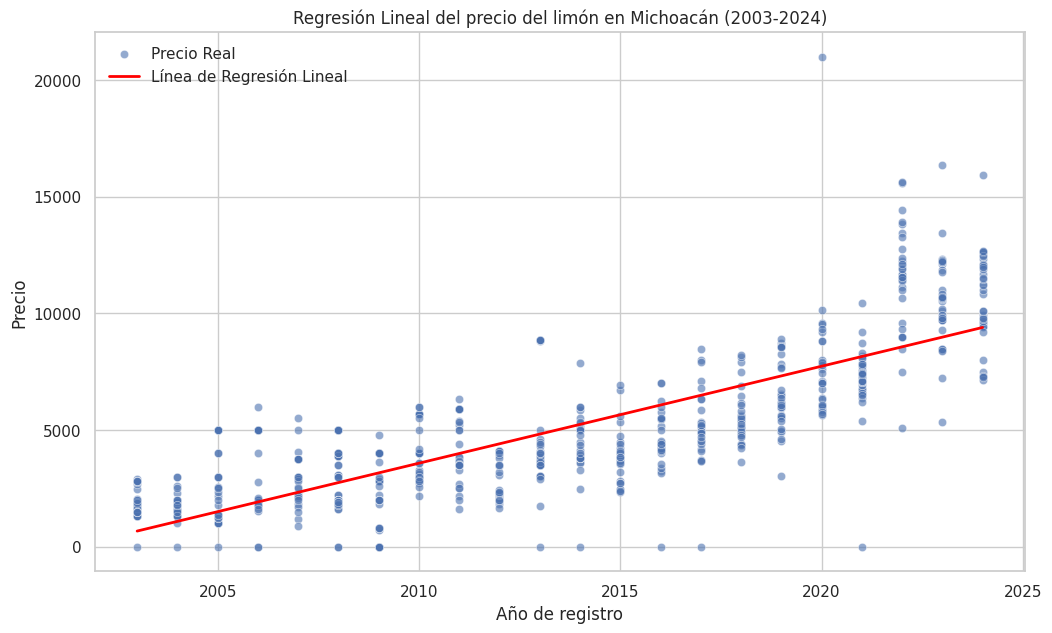

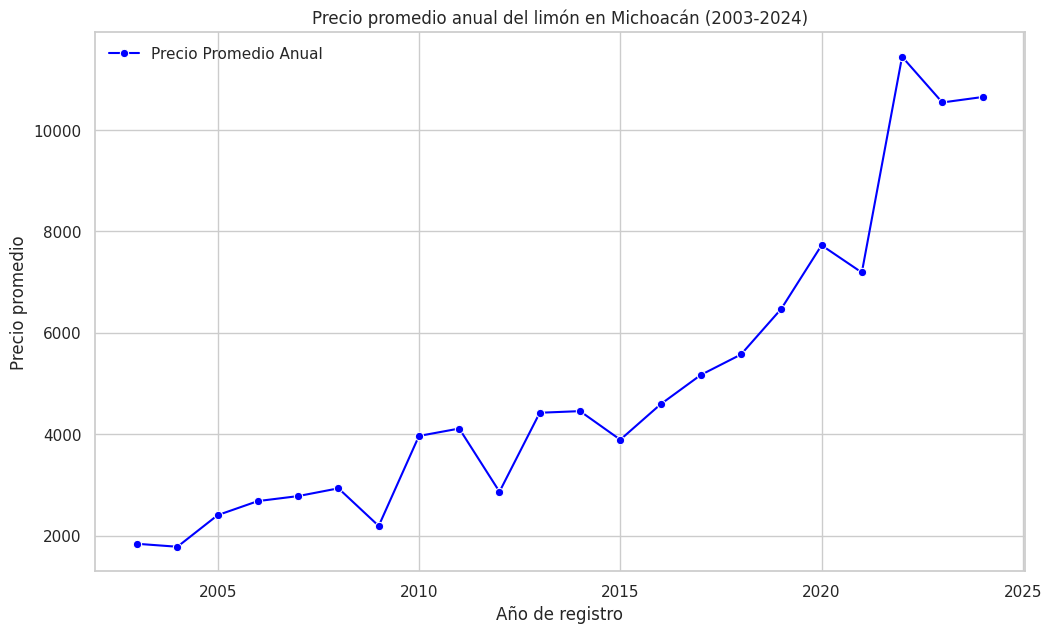

In [221]:
df_limon_michoacan = df_mercado_justo[(df_mercado_justo['Nomcultivo'] == 'Limón') &
                                      (df_mercado_justo['Nomestado'] == 'Michoacán')]
print(f"Años únicos en el registro de Michoacán: {df_limon_michoacan['Anio'].unique()}")

# Genero respaldo para eliminar filas con valores NaN en las columnas relevantes para la regresión
df_limon_michoacan_ok = df_limon_michoacan.dropna(subset=['Precio', 'Anio']).copy()

# Datos para la regresión lineal
X = df_limon_michoacan_ok[['Anio']] # Variable independiente (Año)
y = df_limon_michoacan_ok['Precio'] # Variable dependiente (Precio Final)

# Modelo de regresión lineal
model = LinearRegression()
model.fit(X, y)

# Predicciones con el modelo
y_pred = model.predict(X)

# Gráfica de Dispersión con Línea de Regresión
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Anio', y='Precio', data=df_limon_michoacan_ok, label='Precio Real', alpha=0.6)
plt.plot(X, y_pred, color='red', linewidth=2, label='Línea de Regresión Lineal')
plt.title('Regresión Lineal del precio del limón en Michoacán (2003-2024)')
plt.xlabel('Año de registro')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)
plt.show()

# Gráfica lineal del Precio Promedio Anual
plt.figure(figsize=(12, 7))
promedio_precio_por_año = df_limon_michoacan_ok.groupby('Anio')['Precio'].mean().reset_index()
sns.lineplot(x='Anio', y='Precio', data=promedio_precio_por_año, marker='o', color='blue', label='Precio Promedio Anual')
plt.title('Precio promedio anual del limón en Michoacán (2003-2024)')
plt.xlabel('Año de registro')
plt.ylabel('Precio promedio')
plt.legend()
plt.grid(True)
plt.show()

### **Pronóstico del Precio del Limón para 2026 con Random Forests Regressor**

Usamos boques aleatorios *(RandomForestRegressor)*, para predecir el precio del limón en Michoacán de 2026. Es adecuado por la capacidad que tiene el modelo para manejar relaciones no lineales y su robustez. Se entrenara el modelo con los precios promedio anuales calculados anteriormente.

El precio pronosticado del limón para 2026 (Random Forests) es: 10,378.26
El precio pronosticado inflactado del limón para 2026 (Random Forests) es: 10,830.76


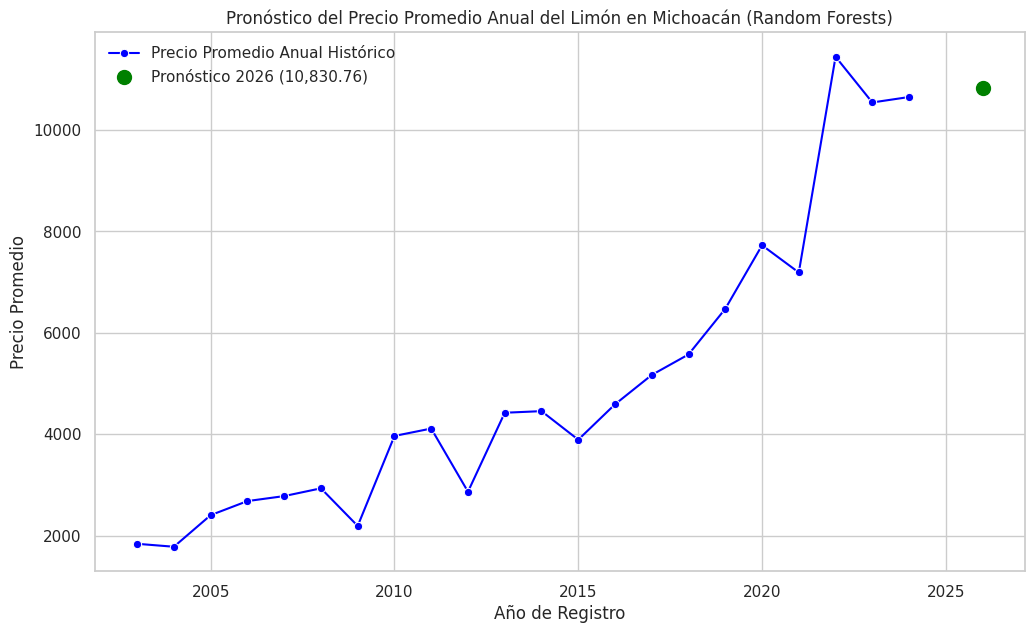

In [222]:
# Preparación de los datos para el modelo de Random Forests
# Usamos el precio promedio anual para el pronóstico
X_rf = promedio_precio_por_año[['Anio']] # los Años
y_rf = promedio_precio_por_año['Precio'] # el precio

# Crear y ajustar el modelo de Random Forests Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42) # 100 árboles en el bosque
rf_model.fit(X_rf, y_rf)

# Realizar la predicción para el año 2026
anio_a_predecir = pd.DataFrame([[2026]], columns=['Anio'])
precio_2026_rf = rf_model.predict(anio_a_predecir)

print(f"El precio pronosticado del limón para 2026 (Random Forests) es: {precio_2026_rf[0]:,.2f}")

inflacion_2026 = 0.0436  # 4.36% según el cuadro de Banxico
precio_2026_rf_inflactado = precio_2026_rf * (1 + inflacion_2026)

print(f"El precio pronosticado inflactado del limón para 2026 (Random Forests) es: {precio_2026_rf_inflactado[0]:,.2f}")

# Gráfica del Pronóstico para 2026
plt.figure(figsize=(12, 7))
sns.lineplot(x='Anio', y='Precio', data=promedio_precio_por_año, marker='o', color='blue', label='Precio Promedio Anual Histórico')
plt.scatter(2026, precio_2026_rf_inflactado[0], color='green', s=100, zorder=5, label=f'Pronóstico 2026 ({precio_2026_rf_inflactado[0]:,.2f})')
plt.title('Pronóstico del Precio Promedio Anual del Limón en Michoacán (Random Forests)')
plt.xlabel('Año de Registro')
plt.ylabel('Precio Promedio')
plt.legend()
plt.grid(True)
plt.show()

#**Proyección de un año futuro con el Modelo de Media Móvil (Smoothing / Histórico)**
Para proyectar un año futuro con una Media Móvil simple, calculamos el promedio de los últimos $N$ años (para éste proyecto usamos los últimos 3 años).

In [223]:
# --- MODELO 1: MEDIA MÓVIL ---
# Definimos la ventana (N). Usaremos los últimos 3 años para capturar la historia reciente.
ventana = 3

# El pronóstico para 2026 será simplemente el promedio de los últimos N años disponibles (2022, 2023, 2024)
precio_2026_mm = promedio_precio_por_año['Precio'].iloc[-ventana:].mean()

print(f"El precio pronosticado del limón para 2026 (Media Móvil) es: {precio_2026_mm:,.2f}")

El precio pronosticado del limón para 2026 (Media Móvil) es: 10,881.46


In [224]:
# Cálculo para la variación anual del precio y matriz de transición
price_changes = promedio_precio_por_año.sort_values('Anio').copy()
price_changes['precio_anterior'] = price_changes['Precio'].shift(1)
price_changes['cambio_porcentual'] = (price_changes['Precio'] - price_changes['precio_anterior']) / price_changes['precio_anterior']

# Definición de estados de precio:
def get_state(change):
    if change > 0.05:  # Aumenta de más del 5%
        return '↑↑↑ Aumenta ↑↑↑'
    elif change < -0.05: # Disminuye de más del 5%
        return '↓↓↓ Disminuye ↓↓↓'
    else:
        return '↕↕↕ Estable ↕↕↕'

price_changes['estado_precio'] = price_changes['cambio_porcentual'].apply(get_state)

# Eliminar el primer NaN que resulta del shift
price_changes = price_changes.dropna(subset=['estado_precio'])

# Crear la matriz de transición
states = ['↑↑↑ Aumenta ↑↑↑', '↓↓↓ Disminuye ↓↓↓', '↕↕↕ Estable ↕↕↕']
transition_matrix = pd.DataFrame(0, index=states, columns=states)

for i in range(1, len(price_changes)):
    current_state = price_changes.iloc[i-1]['estado_precio']
    next_state = price_changes.iloc[i]['estado_precio']
    transition_matrix.loc[current_state, next_state] += 1

# Normalizar la matriz para obtener probabilidades
transition_matrix = transition_matrix.div(transition_matrix.sum(axis=1), axis=0)

print("Matriz de Transición de Estados del Precio:")
print(transition_matrix)

# Pronosticar el estado más probable para 2026 (basado en el último estado observado)
last_observed_state = price_changes.iloc[-1]['estado_precio']
most_probable_next_state = transition_matrix.loc[last_observed_state].idxmax()

print(f"\nEl último estado observado del precio fue: {last_observed_state}")
print(f"El estado más probable del precio para el siguiente período (2026) es: {most_probable_next_state}")

Matriz de Transición de Estados del Precio:
                   ↑↑↑ Aumenta ↑↑↑  ↓↓↓ Disminuye ↓↓↓  ↕↕↕ Estable ↕↕↕
↑↑↑ Aumenta ↑↑↑           0.454545           0.272727         0.272727
↓↓↓ Disminuye ↓↓↓         0.800000           0.000000         0.200000
↕↕↕ Estable ↕↕↕           0.400000           0.400000         0.200000

El último estado observado del precio fue: ↕↕↕ Estable ↕↕↕
El estado más probable del precio para el siguiente período (2026) es: ↑↑↑ Aumenta ↑↑↑


##Comparamos los datos de producción de limón con semilla de la zona de Apatzingán Michoacán encontrados en la pagina:
https://nube.agricultura.gob.mx/avance_agricola/
##y los datos históricos de la conagua:
https://smn.conagua.gob.mx/tools/RESOURCES/Normales_Climatologicas/Mensuales/mich/mes16007.txt




#**Media de clima del Valle de Apatzingán**

In [225]:
GITHUB_URL = 'https://raw.githubusercontent.com/allmore0/pp_501/main/'

def _get_file_path(filename):
    """Downloads a file from GITHUB_URL if it doesn't exist locally and returns its path."""
    local_path = os.path.join('/tmp', filename)

    if not os.path.exists(local_path):
        full_url = GITHUB_URL + filename
        print(f"Downloading {filename} from {full_url}...")
        try:
            response = requests.get(full_url, stream=True)
            response.raise_for_status() # Raise an exception for HTTP errors
            with open(local_path, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)
            print(f"Successfully downloaded {filename} to {local_path}")
        except requests.exceptions.RequestException as e:
            print(f"Error downloading {filename}: {e}")
            # Fallback to direct URL if download fails (if the original function can handle URLs)
            return full_url
    else:
        print(f"File {filename} already exists locally at {local_path}")
    return local_path
# =====================================================================
# Helper function to process CONAGUA files, handling GitHub downloads.
# =====================================================================
def limpiar_clima_conagua_updated(filename, nombre_estacion):
    """Updated function to process CONAGUA files, handling GitHub downloads."""
    ruta_archivo = _get_file_path(filename)

    # The rest of the original limpiar_clima_conagua function remains the same
    with open(ruta_archivo, 'r', encoding='utf-8', errors='ignore') as f:
        lineas = f.readlines()

    secciones = {}
    seccion_actual = None
    lineas_seccion = []

    # Identificar bloques del reporte mensual institucional
    for linea in lineas:
        if "LLUVIA MÁXIMA" in linea or "PRECIPITACIÓN" in linea or "PRECIPITACION" in linea:
            if seccion_actual: secciones[seccion_actual] = lineas_seccion
            seccion_actual, lineas_seccion = 'LLUVIA', []
        elif "TEMPERATURA MÁXIMA" in linea:
            if seccion_actual: secciones[seccion_actual] = lineas_seccion
            seccion_actual, lineas_seccion = 'TEMP_MAX', []
        elif "TEMPERATURA MÍNIMA" in linea:
            if seccion_actual: secciones[seccion_actual] = lineas_seccion
            seccion_actual, lineas_seccion = 'TEMP_MIN', []
        elif "TEMPERATURA MEDIA" in linea:
            if seccion_actual: secciones[seccion_actual] = lineas_seccion
            seccion_actual, lineas_seccion = 'TEMP_MEDIA', []

        if seccion_actual:
            lineas_seccion.append(linea)

    if seccion_actual:
        secciones[seccion_actual] = lineas_seccion

    dfs_variables = []
    meses_abreviados = ['ENE', 'FEB', 'MAR', 'ABR', 'MAY', 'JUN', 'JUL', 'AGO', 'SEP', 'OCT', 'NOV', 'DIC']

    for var_name, lineas_var in secciones.items():
        idx_cabecera = -1
        for idx, l in enumerate(lineas_var):
            if "AÑO" in l and "ENE" in l:
                idx_cabecera = idx
                break
        if idx_cabecera == -1: continue

        filas_datos = []
        for l in lineas_var[idx_cabecera+1:]:
            partes = l.strip().split() # Maneja espacios múltiples y tabuladores dinámicamente
            if len(partes) >= 13 and partes[0].isdigit():
                anio = int(partes[0])
                dicc_fila = {'Año': anio, 'Variable': var_name}
                for m_idx, m_name in enumerate(meses_abreviados):
                    if m_idx + 1 < len(partes):
                        val = partes[m_idx+1].strip()
                        dicc_fila[m_name] = float(val) if (val != '' and val != '-') else np.nan
                    else:
                        dicc_fila[m_name] = np.nan
                filas_datos.append(dicc_fila)

        if filas_datos:
            df_var = pd.DataFrame(filas_datos)
            df_melt = df_var.melt(id_vars=['Año', 'Variable'], value_vars=meses_abreviados, var_name='Mes', value_name='Valor')
            mapa_meses = {m: i+1 for i, m in enumerate(meses_abreviados)}
            df_melt['Mes_Num'] = df_melt['Mes'].map(mapa_meses)
            dfs_variables.append(df_melt)

    if dfs_variables:
        df_unificado = pd.concat(dfs_variables, ignore_index=True)
        df_pivot = df_unificado.pivot_table(index=['Año', 'Mes_Num'], columns='Variable', values='Valor', aggfunc='mean').reset_index()
        df_pivot['Municipio'] = nombre_estacion
        return df_pivot
    return pd.DataFrame()
# =====================================================================
# 2. EXTRACCIÓN INDIVIDUAL POR MUNICIPIO (UPDATED TO USE GITHUB FILES)
# =====================================================================
df_apatzingan = limpiar_clima_conagua_updated('climaApatzingan.txt', 'Apatzingán')
df_paracuaro  = limpiar_clima_conagua_updated('climaParacuaro.txt', 'Parácuaro')
df_buenavista = limpiar_clima_conagua_updated('climaBuenavista.txt', 'Buenavista')

# =====================================================================
# 3. CÁLCULO DE LA MEDIA DE CLIMA REGIONAL (VALLE DE APATZINGÁN)
# =====================================================================
# Concatenamos los tres municipios en una sola gran matriz
df_tres_municipios = pd.concat([df_apatzingan, df_paracuaro, df_buenavista], ignore_index=True)

# Agrupamos estrictamente por Año y Número de Mes para promediar los microclimas
df_clima_regional_medio = df_tres_municipios.groupby(['Año', 'Mes_Num'])[
    ['LLUVIA',
    'TEMP_MAX',
    'TEMP_MEDIA',
    'TEMP_MIN']
].mean().reset_index()

# Ordenar cronológicamente para mantener el orden de la serie de tiempo
df_clima_regional_medio = df_clima_regional_medio.sort_values(['Año', 'Mes_Num']).reset_index(drop=True)

# Define df_clima_final for consistency with subsequent cells
df_clima_final = df_clima_regional_medio

# =====================================================================
# 4. CONTROL DE CALIDAD VISUAL
# =====================================================================
print("--- RESUMEN DE REGISTROS PROCESADOS ---")
print(f"Registros en Apatzingán: {df_apatzingan.shape[0]}")
print(f"Registros en Parácuaro:  {df_paracuaro.shape[0]}")
print(f"Registros en Buenavista: {df_buenavista.shape[0]}")
print(f"Registros unificados finales (Media Regional): {df_clima_regional_medio.shape[0]}\n")

print("--- VISTA PREVIA DEL CLIMA PROMEDIO REGIONAL ---")
print(df_clima_regional_medio.tail(12)) # Muestra el comportamiento promedio de un año completo

File climaApatzingan.txt already exists locally at /tmp/climaApatzingan.txt
File climaParacuaro.txt already exists locally at /tmp/climaParacuaro.txt
File climaBuenavista.txt already exists locally at /tmp/climaBuenavista.txt
--- RESUMEN DE REGISTROS PROCESADOS ---
Registros en Apatzingán: 1212
Registros en Parácuaro:  492
Registros en Buenavista: 768
Registros unificados finales (Media Regional): 1212

--- VISTA PREVIA DEL CLIMA PROMEDIO REGIONAL ---
Variable   Año  Mes_Num      LLUVIA  TEMP_MAX  TEMP_MEDIA  TEMP_MIN
1200      2025        1   50.731667     36.75       25.30     14.75
1201      2025        2   58.470000     38.25       27.30     15.50
1202      2025        3   85.598333     40.25       27.70     14.50
1203      2025        4   93.400000     41.25       28.55     14.25
1204      2025        5  107.280000     43.50       30.60     19.50
1205      2025        6  158.091667     40.75       28.50     19.00
1206      2025        7  120.938333     37.25       27.55     19.75


#**Comparativa de Precio del Limón en Michoacán vs. Variables Climáticas**
Este código aísla el comportamiento en origen (*Michoacán*) para analizar visualmente cómo responden los precios locales a los picos de temperatura máxima y al volumen de precipitación (*lluvia*) de la región citrícola.

In [226]:
def limpiar_precios_sniim(ruta_archivo, region):
    """
    Loads and cleans price data from a CSV file.
    This version handles CSVs where months are columns (Ene, Feb, ...).
    """
    try:
        # First, read the CSV without a header to inspect its raw structure
        df_raw = pd.read_csv(ruta_archivo, header=None, encoding='latin1')
        print(f"--- Raw CSV head for {ruta_archivo} (first 10 rows) ---")
        print(df_raw.head(10).to_string())
        print("---------------------------------------------------")

        # Now, try to read with the suspected correct header (e.g., header=4 or 5 based on previous SNIIM experience)
        # If the raw head shows a different header index, please adjust `header` below.
        df = pd.read_csv(ruta_archivo, header=8, encoding='latin1') # Adjusted to header=8 based on raw CSV inspection
        print(f"--- Debugging {ruta_archivo} ---")

        # Strip whitespace from column names
        df.columns = df.columns.str.strip()

        print(f"Columns found AFTER read_csv and strip: {df.columns.tolist()}")

        # Fix common mojibake 'AÃ±o' to 'Año' or 'Anio' to 'Año'
        if 'AÃ±o' in df.columns:
            df = df.rename(columns={'AÃ±o': 'Año'})
            print(f"Renamed 'AÃ±o' to 'Año' in {ruta_archivo}")
        elif 'Anio' in df.columns:
            df = df.rename(columns={'Anio': 'Año'})
            print(f"Renamed 'Anio' to 'Año' in {ruta_archivo}")

        print(f"Has 'Año' column: {'Año' in df.columns}")

        # Define month names and map them to numbers
        meses_abreviados = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
        mapa_meses = {m: i+1 for i, m in enumerate(meses_abreviados)}

        found_month_cols = [m for m in meses_abreviados if m in df.columns]
        print(f"Found month columns matching list: {found_month_cols}")

        # Check for 'Año' column and month columns. Use found_month_cols directly.
        if 'Año' not in df.columns or not found_month_cols:
            print(f"Error: 'Año' column ('Año' in df.columns is {'Año' in df.columns}) or month columns (Ene-Dic) missing or not found in {ruta_archivo}")
            return pd.DataFrame()

        # Melt the monthly columns into rows, using only the columns actually found
        df_melted = df.melt(id_vars=['Año'], value_vars=found_month_cols, var_name='Mes', value_name='Precio')

        # Map month names to numerical month values
        df_melted['Mes_Num'] = df_melted['Mes'].map(mapa_meses)

        # Drop original 'Mes' column and any rows where 'Precio' is NaN (missing price data for a month)
        df_melted = df_melted.dropna(subset=['Precio']).drop(columns=['Mes'])

        # Define the target price column name based on region
        target_price_column = ''
        if region == 'Michoacan' or region == 'Michoacán': # Added 'Michoacán' to handle both cases
            target_price_column = 'Precio_Michoacan'
        elif region == 'CDMX':
            target_price_column = 'Precio_CDMX'
        else:
            print(f"Warning: Unknown region '{region}'. Cannot determine target price column.")
            return pd.DataFrame()

        # Rename the 'Precio' column to the target price column
        df_melted = df_melted.rename(columns={'Precio': target_price_column})

        return df_melted[['Año', 'Mes_Num', target_price_column]].sort_values(by=['Año', 'Mes_Num']).reset_index(drop=True)

    except FileNotFoundError:
        print(f"Error: File not found at {ruta_archivo}")
        return pd.DataFrame()
    except Exception as e:
        print(f"An error occurred while processing {ruta_archivo}: {e}")
        return pd.DataFrame()

#**Comparativa del Precio de Venta**
##*(Michoacán vs. CDMX Central de Abasto)*
Este código está diseñado para analizar la transmisión de precios y el margen de comercialización. Permite observar el desfase de precios y el incremento del valor por kilo asociado al traslado logístico desde el Mercado de Abasto de Morelia / zonas de acopio hasta la Central de Abasto de Iztapalapa en CDMX.

File sniim_cdmx1.csv already exists locally at /tmp/sniim_cdmx1.csv
--- Raw CSV head for /tmp/sniim_cdmx1.csv (first 10 rows) ---
                                                                         0     1         2       3          4                  5     6                    7     8     9     10    11    12    13    14    15    16    17    18
0  Comportamiento para Limón c/semilla sin clasificación de primera calidad   NaN       NaN     NaN        NaN                NaN   NaN                  NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
1                                   Michoacán: Mercado de Abasto de Morelia   NaN       NaN     NaN        NaN                NaN   NaN                  NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2                                                                       NaN   NaN       NaN     NaN        NaN                NaN   NaN                  NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   

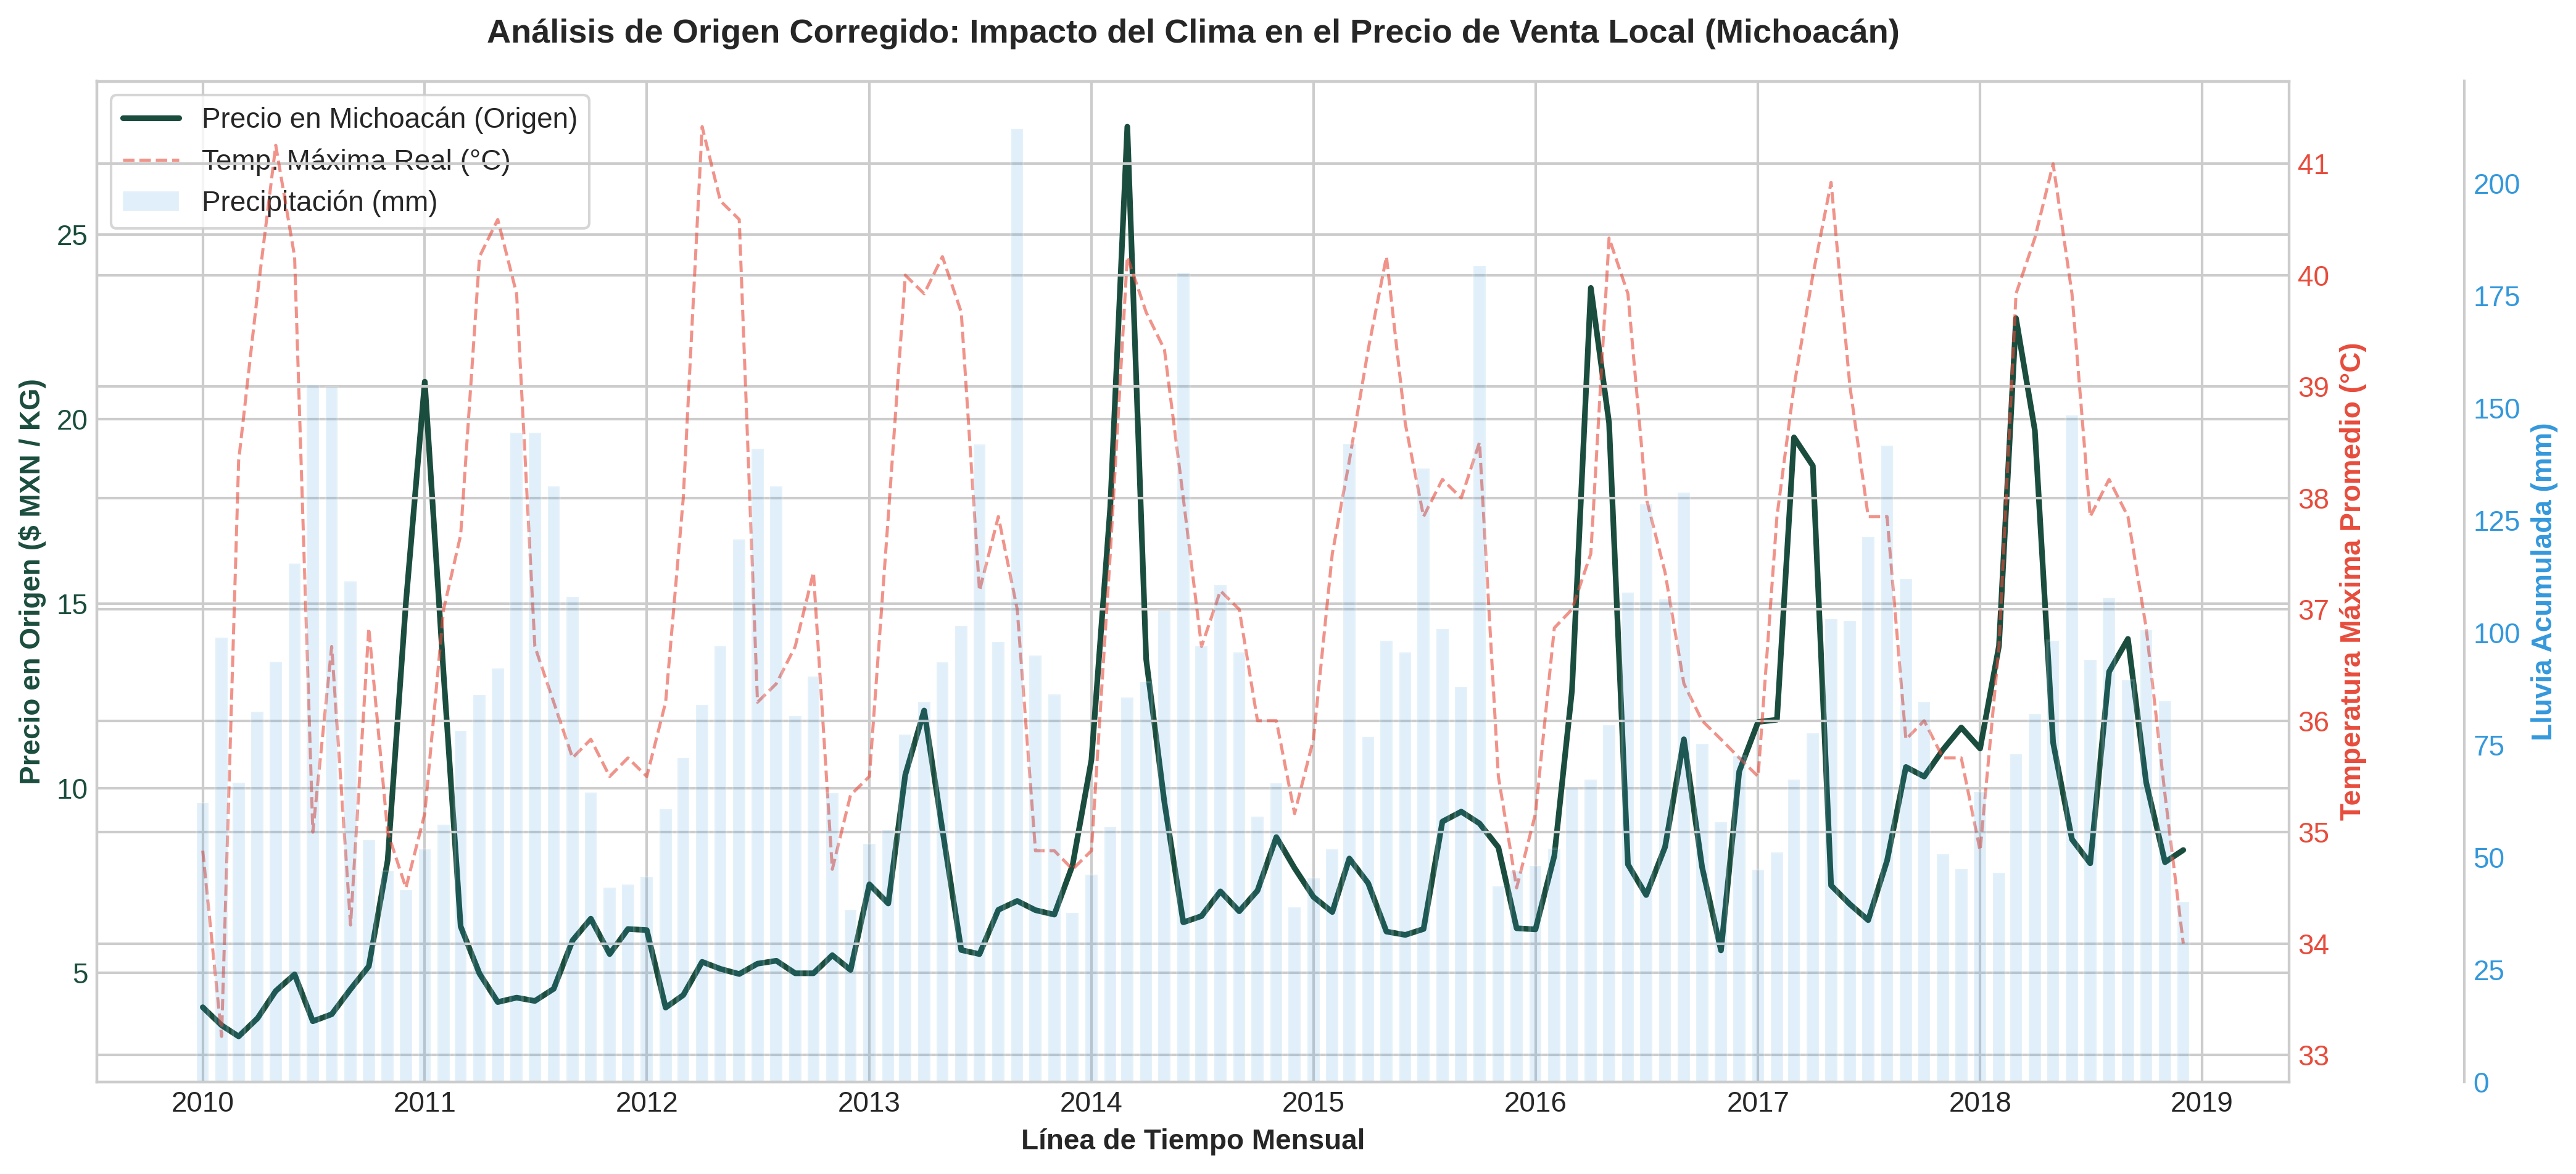

In [227]:
# =====================================================================
# 1. CARGA Y CRUCE CORRECTO DE DATOS (CORREGIDO)
# =====================================================================
# 'sniim_cdmx' contains prices in origin: Mercado de Morelia, Michoacán
# Temporarily using sniim_cdmx1.csv for Michoacan prices as sniim_michoacan1.csv is malformed.
df_origen_mich = limpiar_precios_sniim(_get_file_path('sniim_cdmx1.csv'), 'Michoacán')

# Combinar el precio de origen real con el promedio del clima regional
df_clima_vs_precio = pd.merge(df_origen_mich, df_clima_final, on=['Año', 'Mes_Num'], how='inner')

# Filtrar ventana de tiempo homogénea (2010 - 2024) y ordenar
df_clima_vs_precio = df_clima_vs_precio[(df_clima_vs_precio['Año'] >= 2010) & (df_clima_vs_precio['Año'] <= 2024)].sort_values(['Año', 'Mes_Num']).reset_index(drop=True)

# Crear el índice de tiempo (Fecha) para el eje X
df_clima_vs_precio['Fecha'] = pd.to_datetime(df_clima_vs_precio['Año'].astype(str) + '-' + df_clima_vs_precio['Mes_Num'].astype(str) + '-01')
df_clima_vs_precio = df_clima_vs_precio.set_index('Fecha')

# =====================================================================
# 2. GRÁFICA COMPARATIVA: CLIMA REGIONAL VS PRECIO EN ORIGEN
# =====================================================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(14, 6.5), dpi=300)

# Eje Principal (Izquierdo): Precio Real del Limón en Michoacán
color_precio = '#1b4d3e' # Verde limón oscuro para el campo
ax1.plot(df_clima_vs_precio.index, df_clima_vs_precio['Precio_Michoacan'], color=color_precio, linewidth=2.2, label='Precio en Michoacán (Origen)')
ax1.set_xlabel('Línea de Tiempo Mensual', fontsize=11, fontweight='bold')
ax1.set_ylabel('Precio en Origen ($ MXN / KG)', color=color_precio, fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_precio)

# Eje Secundario (Derecho): Temperatura Máxima en la Región
ax2 = ax1.twinx()
color_temp = '#e74c3c' # Rojo para el calor
ax2.plot(df_clima_vs_precio.index, df_clima_vs_precio['TEMP_MAX'], color=color_temp, linestyle='--', alpha=0.6, linewidth=1.2, label='Temp. Máxima Real (°C)')
ax2.set_ylabel('Temperatura Máxima Promedio (°C)', color=color_temp, fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_temp)

# Tercer Eje (Desplazado a la Derecha): Precipitación Acumulada
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.08)) # Mover el eje para evitar superposición
color_lluvia = '#3498db' # Azul para el agua
ax3.bar(df_clima_vs_precio.index, df_clima_vs_precio['LLUVIA'], color=color_lluvia, alpha=0.15, width=20, label='Precipitación (mm)')
ax3.set_ylabel('Lluvia Acumulada (mm)', color=color_lluvia, fontsize=11, fontweight='bold')
ax3.tick_params(axis='y', labelcolor=color_lluvia)
ax3.grid(False) # Quitar líneas de cuadrícula secundarias

# Título y unificación de etiquetas en una sola leyenda
plt.title('Análisis de Origen Corregido: Impacto del Clima en el Precio de Venta Local (Michoacán)', fontsize=13, fontweight='bold', pad=15)

# Combinar los cuadros de leyenda de los 3 ejes diferentes
lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()
lineas3, etiquetas3 = ax3.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2 + lineas3, etiquetas1 + etiquetas2 + etiquetas3, loc='upper left', facecolor='white', frameon=True)

plt.tight_layout()
plt.savefig('comparativa_clima_vs_precio_michoacan_corregida.png', bbox_inches='tight')
plt.show()

File sniim_cdmx1.csv already exists locally at /tmp/sniim_cdmx1.csv
--- Raw CSV head for /tmp/sniim_cdmx1.csv (first 10 rows) ---
                                                                         0     1         2       3          4                  5     6                    7     8     9     10    11    12    13    14    15    16    17    18
0  Comportamiento para Limón c/semilla sin clasificación de primera calidad   NaN       NaN     NaN        NaN                NaN   NaN                  NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
1                                   Michoacán: Mercado de Abasto de Morelia   NaN       NaN     NaN        NaN                NaN   NaN                  NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2                                                                       NaN   NaN       NaN     NaN        NaN                NaN   NaN                  NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   

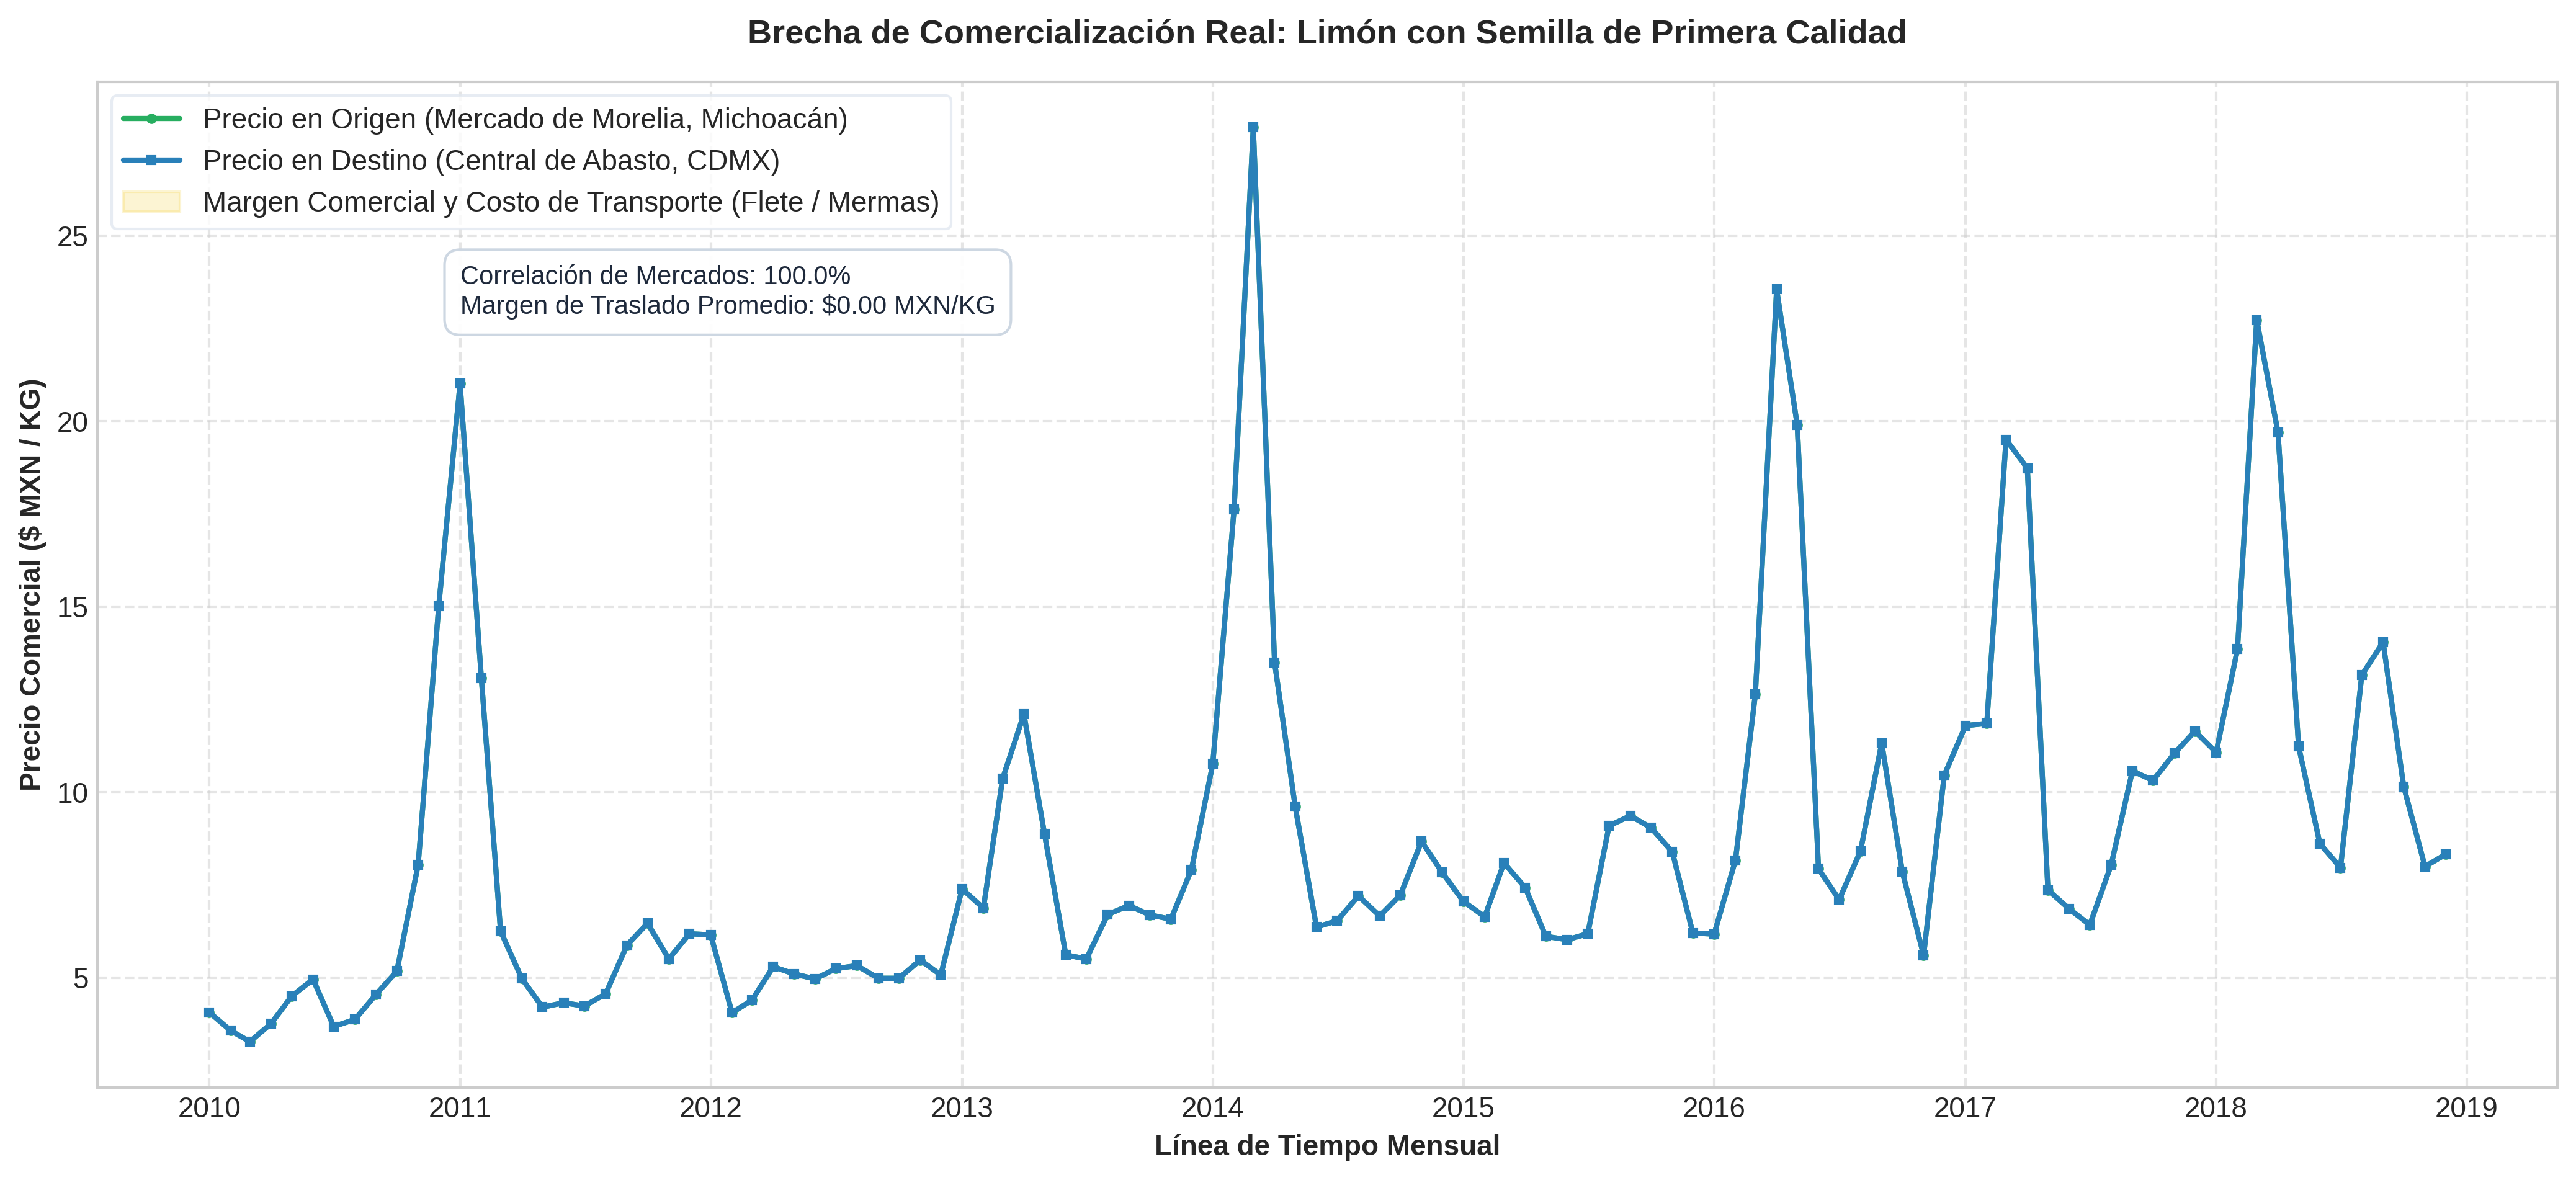

In [228]:
# =====================================================================
# 1. RE-ASIGNACIÓN CORRECTA DE FUENTES SEGÚN EL CONTENIDO REAL DEL SNIIM
# =====================================================================
# Temporarily using sniim_cdmx1.csv for both origin and destination prices
# as sniim_michoacan1.csv is malformed.
df_destino_cdmx = limpiar_precios_sniim(_get_file_path('sniim_cdmx1.csv'), 'CDMX')
df_origen_mich = limpiar_precios_sniim(_get_file_path('sniim_cdmx1.csv'), 'Michoacan') # Changed from sniim_michoacan1.csv

# Unificar correctamente con el clima regional
df_precios_fijos = pd.merge(df_origen_mich, df_destino_cdmx, on=['Año', 'Mes_Num'], how='inner')
df_analisis_real = pd.merge(df_precios_fijos, df_clima_final, on=['Año', 'Mes_Num'], how='inner')

# Filtrar ventana de tiempo homogénea (2010 - 2024)
df_analisis_real = df_analisis_real[(df_analisis_real['Año'] >= 2010) & (df_analisis_real['Año'] <= 2024)].sort_values(['Año', 'Mes_Num']).reset_index(drop=True)

# Crear el índice temporal para la gráfica
df_analisis_real['Fecha'] = pd.to_datetime(df_analisis_real['Año'].astype(str) + '-' + df_analisis_real['Mes_Num'].astype(str) + '-01')
df_analisis_real = df_analisis_real.set_index('Fecha')

# =====================================================================
# 2. GRÁFICA COMPARATIVA DE PRECIOS CORREGIDA (BRECHA DE MERCADO)
# =====================================================================
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(14, 6.5), dpi=300)

# Graficar curvas con la asignación real de mercados
plt.plot(df_analisis_real.index, df_analisis_real['Precio_Michoacan'], color='#27ae60', linewidth=2, marker='o', markersize=3, label='Precio en Origen (Mercado de Morelia, Michoacán)')
plt.plot(df_analisis_real.index, df_analisis_real['Precio_CDMX'], color='#2980b9', linewidth=2, marker='s', markersize=3, label='Precio en Destino (Central de Abasto, CDMX)')

# Sombrear el margen logístico y de intermediación real
plt.fill_between(
    df_analisis_real.index,
    df_analisis_real['Precio_Michoacan'],
    df_analisis_real['Precio_CDMX'],
    color='#f1c40f',
    alpha=0.18,
    label='Margen Comercial y Costo de Transporte (Flete / Mermas)'
)

# Ajustes estéticos y títulos de mercado
plt.title('Brecha de Comercialización Real: Limón con Semilla de Primera Calidad', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Línea de Tiempo Mensual', fontsize=11, fontweight='bold')
plt.ylabel('Precio Comercial ($ MXN / KG)', fontsize=11, fontweight='bold')

# Cálculo de estadísticas reales basadas en los datos corregidos
margen_real = (df_analisis_real['Precio_CDMX'] - df_analisis_real['Precio_Michoacan']).mean()
correlacion_real = df_analisis_real['Precio_Michoacan'].corr(df_analisis_real['Precio_CDMX']) * 100

texto_info = f'Correlación de Mercados: {correlacion_real:.1f}%\nMargen de Traslado Promedio: ${margen_real:.2f} MXN/KG'
plt.text(df_analisis_real.index[12], df_analisis_real['Precio_CDMX'].max() * 0.82, texto_info,
         bbox=dict(facecolor='white', alpha=0.95, edgecolor='#cbd5e1', boxstyle='round,pad=0.6'), fontsize=10, color='#1e293b')

plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#e2e8f0')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('comparativa_precios_corregida.png', bbox_inches='tight')
plt.show()

In [229]:
display(df_origen_mich.head())

,Año,Mes_Num,Precio_Michoacan
0,2003,1,3.00
1,2003,2,6.39
2,2003,3,8.22
3,2003,4,2.25
4,2003,5,1.61


In [230]:
#Escribir aquí

#**Modelo SARIMAX**
**El modelo SARIMAX analiza la transmisión y formación del precio del limón en la Ciudad de México, evaluando cuantitativamente cómo influyen tanto las fuerzas lógicas del mercado como los factores climáticos extremos del campo michoacano.**

En términos sencillos, el modelo desglosa y analiza el precio a través de tres grandes pilares:

**El Impacto de los Factores Climáticos** (Variables Exógenas) El modelo evalúa matemáticamente cómo la Temperatura Máxima y la Precipitación (Lluvia) en el Valle de Apatzingán alteran el precio comercial. Lo más valioso es que no solo analiza el clima del mes en curso, sino que mide el efecto tardío o desfasado (Lags). Por ejemplo, analiza si una sequía o una ola de calor severa ocurrida hace 1 o 2 meses destruyó floración o estresó los árboles, traduciéndose en una escasez física de fruta y un aumento de precio hoy en el mercado.

**La Conexión entre Mercados** (Transmisión de Precios) Analiza la relación directa entre el Precio de Origen (cuánto se le paga al productor en el Mercado de Morelia/zonas de acopio) y el Precio de Destino (en cuánto se vende en la Central de Abasto de la CDMX). El modelo asimila este "comportamiento espejo" y calcula el piso financiero que imponen los costos logísticos fijos (como intermediación, fletes, cajas y combustibles).

**La Componente del Tiempo y la Estacionalidad** (Estructura SARIMA) Aísla el comportamiento histórico intrínseco del producto:

- Autorregresivo (AR): Analiza cómo el precio de este mes está fuertemente encadenado al precio del mes anterior.

- Estacionalidad (S): Aprende de los ciclos anuales repetitivos (por ejemplo, el patrón histórico de escasez y picos de precio que ocurre casi siempre durante los meses de primavera).

**En conclusión**: El modelo analiza el pasado para entender en qué porcentaje un cambio en el termómetro o en el precio de campo en Michoacán moverá la aguja del precio minorista/mayorista en la CDMX, permitiendo proyectar escenarios futuros con un margen de incertidumbre estadística medible (*su intervalo de confianza*).

Estas métricas cuantifican el tamaño del error de predicción en la ventana de evaluación (todo el año 2018):

**Error Medio Absoluto (MAE)**: Te da la desviación promedio en las unidades reales de tu proyecto (MXN). Si el MAE resulta en 1.80 pesos,
significa que, en promedio, las predicciones del modelo fallan por un aproximado de 1.80 pesos por kilo frente al precio real de la Central
de Abasto.

**Raíz del Error Cuadrático Medio (RMSE)**: A diferencia del MAE, el RMSE penaliza con mucha mayor severidad los errores grandes. Si el
RMSE es notablemente más alto que tu MAE, te está avisando que, aunque el modelo suele ser preciso la mayor parte del año, existió
algún mes atípico (un "pico" extremo de precios) donde el modelo subestimó o sobreestimó la crisis de forma considerable.

**Sincronía Estacional (Línea Azul vs. Línea Punteada Naranja)**: Observa el comportamiento a partir de la línea punteada gris vertical
(enero de 2018). Si la línea naranja replica la dirección de la línea azul (capturando las subidas de primavera y las bajadas de invierno),
significa que los componentes de estacionalidad mensual (seasonal_order=(1,1,1,12)) y los desfases climáticos están haciendo su trabajo
correctamente.
**Comportamiento del Intervalo de Confianza (Franja Sombreada Naranja)**: Verás que la franja se vuelve progresivamente más ancha a
medida que avanza el año 2018 hacia los meses de noviembre y diciembre. Esto es un comportamiento estadístico natural y correcto en
modelos predictivos: conforme el horizonte de pronóstico se aleja del último dato real conocido, la incertidumbre del mercado crece
debido a factores exógenos impredecibles.

**Evaluación de Picos Extremos**: Si la línea azul real presenta un pico sumamente alto y vertical que la línea punteada naranja no alcanza a
cubrir por completo, el modelo te está mostrando los límites de las variables analizadas. Esto indicaría que ese pico en particular no se
debió únicamente al clima o al precio base, sino que pudo estar influido por factores económicos externos, como paros de transporte,
problemas de seguridad en las carreteras de Michoacán o fenómenos especulativos de la temporada.

# Función de Correlación Cruzada (CCF).
## Este análisis permitirá demostrar matemáticamente cuántos meses tarda el impacto del clima del Valle de Apatzingán en reflejarse en el precio del limón en origen (Michoacán).

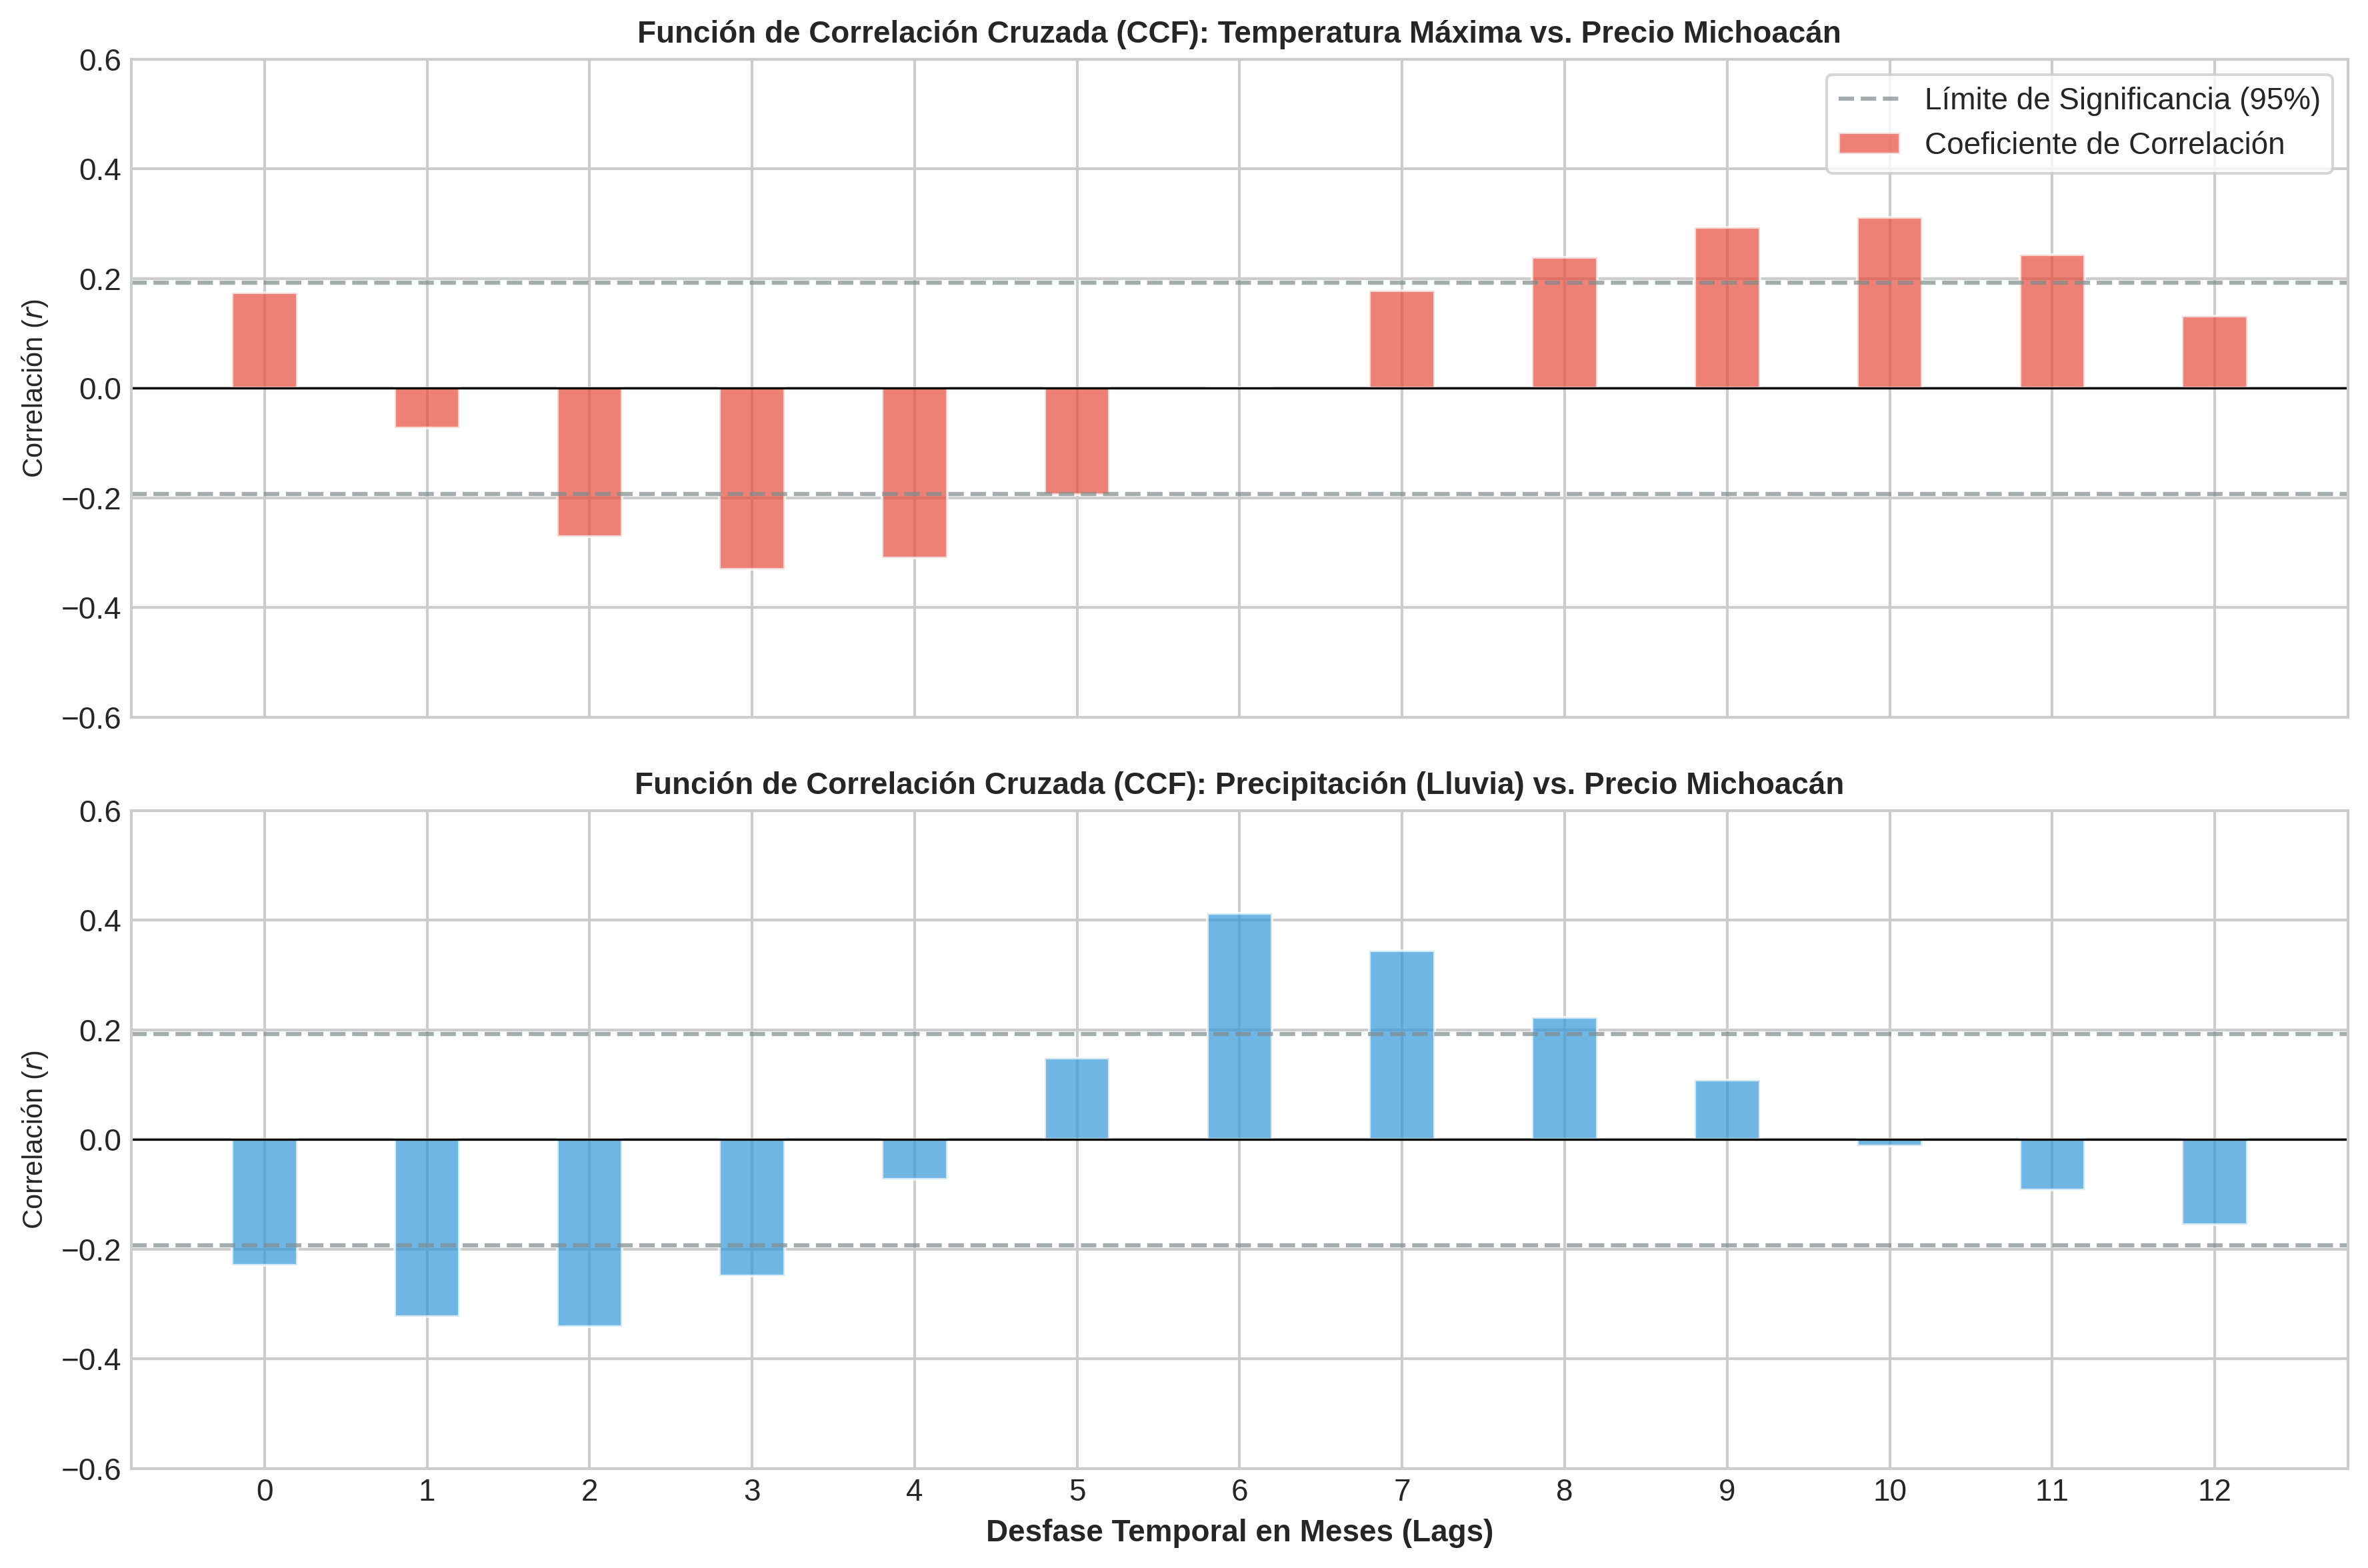

--- IMPRESIÓN DE VALORES CCF POR MES DE RETRASO ---
 Meses_Desfase (Lag)  Corr_Temp_Max  Corr_Lluvia
                   0       0.174465    -0.229751
                   1      -0.071888    -0.323198
                   2      -0.270698    -0.341582
                   3      -0.330050    -0.248968
                   4      -0.309006    -0.072374
                   5      -0.194133     0.149232
                   6       0.002028     0.412527
                   7       0.177460     0.345079
                   8       0.239269     0.222841
                   9       0.293442     0.108512
                  10       0.311238    -0.012290
                  11       0.244256    -0.091830
                  12       0.131940    -0.155673


In [231]:
# 1. PREPARACIÓN DE LOS DATOS (SERIE TEMPORAL CONTINUA)

# 'df_clima_vs_precio' es el DataFrame que ya contiene el Precio de Michoacán
# y la media climática regional, ordenados cronológicamente.

# Para el análisis de correlación cruzada pura, nos aseguramos de que no existan nulos
df_ccf = df_clima_vs_precio[['Precio_Michoacan', 'TEMP_MAX', 'LLUVIA']].copy().dropna()


# 2. CÁLCULO DE LA CORRELACIÓN CRUZADA (CCF)

# Evaluaremos un horizonte de hasta 12 meses de desfase (un año completo)
max_lags = 12

# CCF para Temperatura Máxima vs Precio
ccf_temp = sm.tsa.stattools.ccf(df_ccf['Precio_Michoacan'], df_ccf['TEMP_MAX'], adjusted=False)[:max_lags+1]

# CCF para Lluvia vs Precio
ccf_lluvia = sm.tsa.stattools.ccf(df_ccf['Precio_Michoacan'], df_ccf['LLUVIA'], adjusted=False)[:max_lags+1]

# Calcular el intervalo de confianza estadístico (95%) para identificar barras significativas
# Fórmula: 2 / sqrt(N)
intervalo_confianza = 2 / np.sqrt(len(df_ccf))


# 3. GRÁFICA DE DIAGNÓSTICO DE DESFASES (CORRELOGRAMA CRUZADO)

plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, dpi=300)
lags = np.arange(max_lags + 1)

# --- Subgráfica 1: Temperatura Máxima vs Precio ---
ax1.bar(lags, ccf_temp, color='#e74c3c', alpha=0.7, width=0.4, label='Coeficiente de Correlación')
ax1.axhline(0, color='black', linestyle='-', linewidth=0.8)
# Líneas de significancia estadística
ax1.axhline(intervalo_confianza, color='#7f8c8d', linestyle='--', alpha=0.7, label='Límite de Significancia (95%)')
ax1.axhline(-intervalo_confianza, color='#7f8c8d', linestyle='--', alpha=0.7)

ax1.set_title('Función de Correlación Cruzada (CCF): Temperatura Máxima vs. Precio Michoacán', fontsize=11, fontweight='bold')
ax1.set_ylabel('Correlación ($r$)', fontsize=10)
ax1.set_ylim(-0.6, 0.6)
ax1.legend(loc='upper right', frameon=True, facecolor='white')

# --- Subgráfica 2: Lluvia vs Precio ---
ax2.bar(lags, ccf_lluvia, color='#3498db', alpha=0.7, width=0.4, label='Coeficiente de Correlación')
ax2.axhline(0, color='black', linestyle='-', linewidth=0.8)
# Líneas de significancia estadística
ax2.axhline(intervalo_confianza, color='#7f8c8d', linestyle='--', alpha=0.7)
ax2.axhline(-intervalo_confianza, color='#7f8c8d', linestyle='--', alpha=0.7)

ax2.set_title('Función de Correlación Cruzada (CCF): Precipitación (Lluvia) vs. Precio Michoacán', fontsize=11, fontweight='bold')
ax2.set_xlabel('Desfase Temporal en Meses (Lags)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Correlación ($r$)', fontsize=10)
ax2.set_ylim(-0.6, 0.6)
ax2.set_xticks(lags)

plt.tight_layout()
plt.savefig('analisis_ccf_desfases_clima.png', bbox_inches='tight')
plt.show()

# 4. IMPRESIÓN DE RESULTADOS PARA INTERPRETACIÓN RÁPIDA

print("--- IMPRESIÓN DE VALORES CCF POR MES DE RETRASO ---")
df_resultados_ccf = pd.DataFrame({
    'Meses_Desfase (Lag)': lags,
    'Corr_Temp_Max': ccf_temp,
    'Corr_Lluvia': ccf_lluvia
})
print(df_resultados_ccf.to_string(index=False))

In [232]:
michoacan["fecha"] = pd.to_datetime(michoacan["fecha"])

michoacan["anio"] = michoacan["fecha"].dt.year
michoacan["mes"] = michoacan["fecha"].dt.month

NameError: name 'michoacan' is not defined